In [99]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [100]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import utils

In [101]:
def to_homogeneous_2d(points: np.ndarray) -> np.ndarray:
    """
    Transforms each point in `points` to homogeneous coordinates.

    :param points: Shape ``(n, 2)``, with ``n`` being the number of points.
    """
    ones: np.ndarray = np.ones((len(points), 1))
    return np.concatenate((points, ones), axis=1)


def to_inhomogeneous_2d(points: np.ndarray) -> np.ndarray:
    """
    Transforms each point in `points` to inhomogeneous coordinates.

    :param points: Shape ``(n, 3)``, with ``n`` being the number of points.
    """
    return (points / points[:, -1][:, None])[:, :2]

## General Projectivity

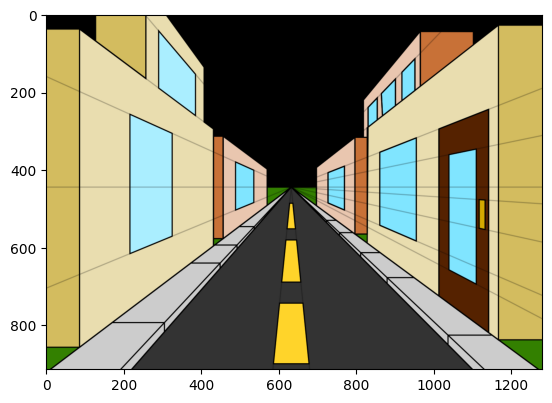

In [102]:
img: np.ndarray = cv.imread("road.png", cv.IMREAD_COLOR_RGB)

plt.imshow(img)
plt.show()

In [103]:
h: np.array = np.array(
    [
        [1.5, 0.2, 10],
        [0.2, 1, -15],
        [0, 0, 1],
    ],
    np.float64,
)
h_inv: np.ndarray = np.linalg.inv(h)

print("Inverse homography:\n", h_inv)

Inverse homography:
 [[ 0.68493151 -0.1369863  -8.90410959]
 [-0.1369863   1.02739726 16.78082192]
 [ 0.          0.          1.        ]]


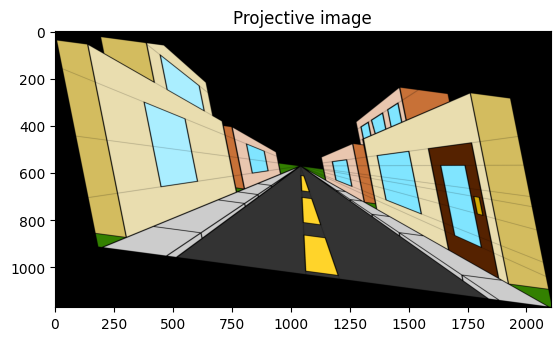

In [104]:
img_p: np.ndarray = utils.warp(img, h)

plt.imshow(img_p)
plt.title("Projective image")
plt.show()

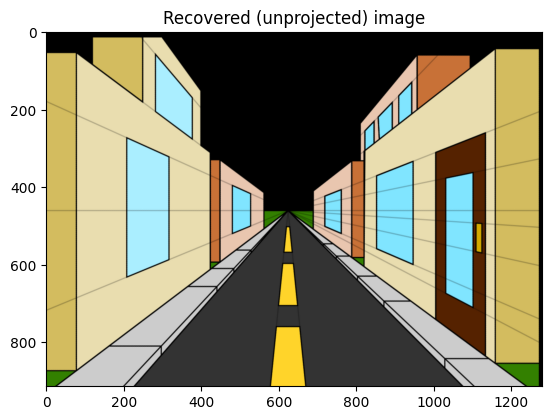

In [105]:
size: tuple[float, float] = img.shape[:2][::-1]
recovered_img: np.ndarray = cv.warpPerspective(img_p, h_inv, size)

plt.imshow(recovered_img)
plt.title("Recovered (unprojected) image")
plt.show()

## Isometries

In [106]:
def isometry(theta: float = 0, tx: float = 0, ty: float = 0) -> np.ndarray:
    """
    Creates and isometry with the given parameters.
    """
    return np.array(
        [
            [np.cos(theta), -np.sin(theta), tx],
            [np.sin(theta), np.cos(theta), ty],
            [0, 0, 1],
        ]
    )

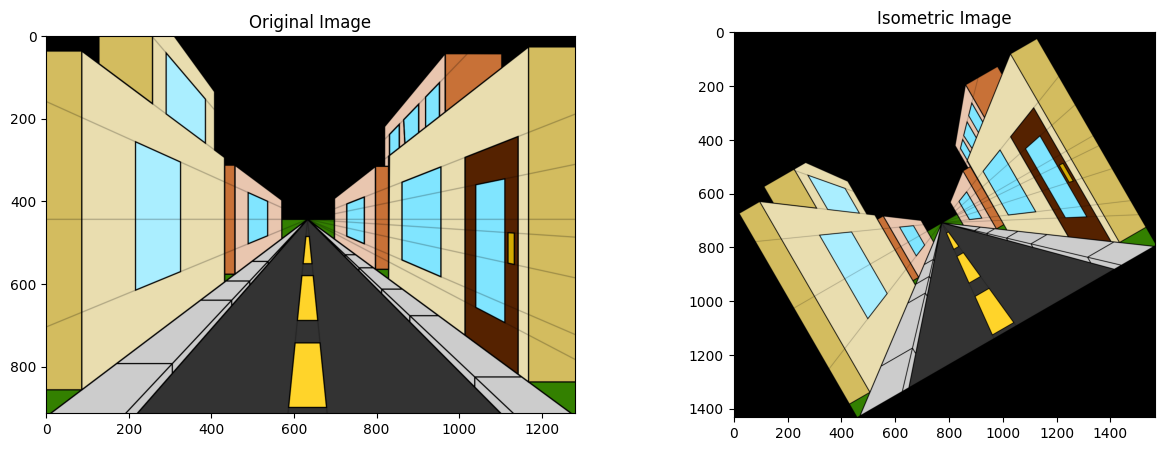

In [107]:
he: np.ndarray = isometry(np.radians(-30), 50, 100)

img_proj: np.ndarray = utils.warp(img, he)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[1].imshow(img_proj)
axes[1].set_title("Isometric Image")
plt.show()

## Recover Isometry from 2 Point Correspondences

In [108]:
x: np.ndarray = np.array([[50, 50, 1], [80, 100, 1]], np.float64)
xp: np.ndarray = x @ he.T

print("Correspondences:", x, xp, sep="\n")

Correspondences:
[[ 50.  50.   1.]
 [ 80. 100.   1.]]
[[118.30127019 118.30127019   1.        ]
 [169.2820323  146.60254038   1.        ]]


In [109]:
def recover_isometry(points: np.ndarray, p_points: np.ndarray) -> np.ndarray:
    """
    Computes an isometry given a set of point correspondences.
    """
    # System of equations creation.
    a: list = []
    for (x, y, _), (xp, yp, _) in zip(points, p_points):
        a.append([x, -y, 1, 0, -xp])
        a.append([y, x, 0, 1, -yp])
    a: np.ndarray = np.array(a)
    # Solution to the system of equations.
    _, _, sol = np.linalg.svd(a)
    cos, sin, tx, ty, s = sol[-1]
    # Isometry creation.
    return np.array(
        [
            [cos, -sin, tx],
            [sin, cos, ty],
            [0, 0, s],
        ]
    ) / s

In [110]:
he_recovered: np.ndarray = recover_isometry(x, xp)
print(he_recovered)

[[  0.8660254   0.5        50.       ]
 [ -0.5         0.8660254 100.       ]
 [  0.          0.          1.       ]]


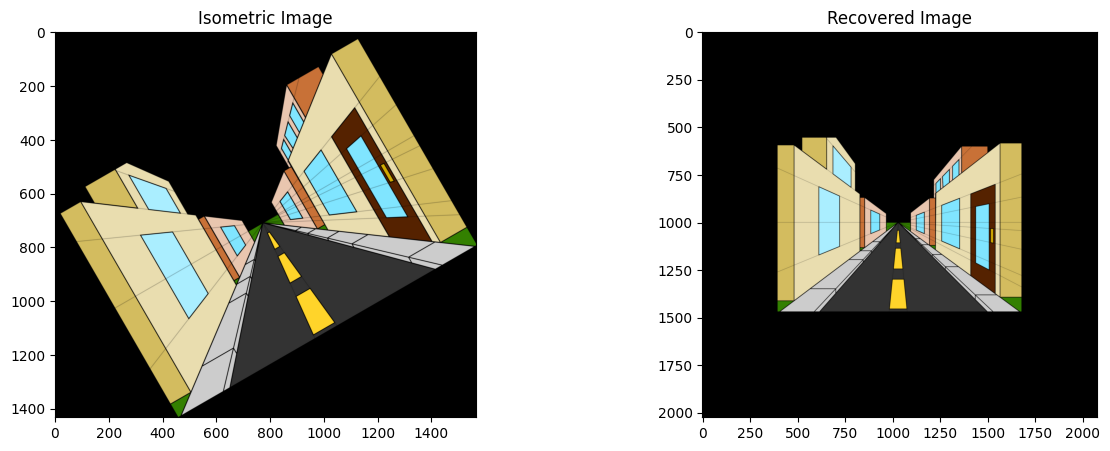

In [111]:
he_recovered_inv: np.ndarray = np.linalg.inv(he_recovered)

img_orig: np.ndarray = utils.warp(img_proj, he_recovered_inv)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(img_proj)
axes[0].set_title("Isometric Image")
axes[1].imshow(img_orig)
axes[1].set_title("Recovered Image")
plt.show()